# Actividad 2_8: 

Descarga los dos ficheros adjuntos que encontrarás con la tarea. Uno de ellos contiene un dataset con el precio mensual de la cuenta de Netflix por países. El otro contiene datos sobre los salarios por países. El objetivo de esta actividad es contestar a la siguiente pregunta. ¿Existe relación entre la media o la mediana de los salarios de los países y la cuota mensual que se paga por Netflix?

Debes escribir un programa que realice las siguientes tareas:

1. Importar los dos datasets adjuntos con la tarea y guardarlos en dos Dataframes. Analiza los datos.
2. Crea un DataFrame que incluya una columna con el coste mensual standars de Netflix, otra con el salario medio y otra con la mediana.
3. Normaliza los datos del DataFrame creado en el punto 3. Normalizar los datos consiste en escalar los valores para que tengan un rango similar. En este caso nos sirve para poder comparar el coste mensual de Netflix con el salario de una persona (que tendrán inicialmente un rango muy distinto). Hay muchos métodos para normalizar. En pandas tenemos algunos métodos que puedes encontrar en el enlace a continuación. Puedes usar uno o probar varios. Si haces esto último debes hacer varios métodos.

https://www.geeksforgeeks.org/normalize-a-column-in-pandas/

4. Finalmente debes pintar una gráfica con los datos por países ya normalizados y contestar a la pregunta. ¿Existe relación entre lo que gana una persona en cada país y lo que debe pagar por Netflix?

In [9]:
import pandas as pd

df_netflix = pd.read_csv("Netflix subscription fee Dec-2021.csv")
df_salarios = pd.read_csv("salaries_by_country_2021.csv")

df_netflix.head()
#print(df_salarios.head())


,Country_code,Country,Total Library Size,No. of TV Shows,No. of Movies,Cost Per Month - Basic ($),Cost Per Month - Standard ($),Cost Per Month - Premium ($)
0,ar,Argentina,4760,3154,1606,3.74,6.30,9.26
1,au,Australia,6114,4050,2064,7.84,12.12,16.39
2,at,Austria,5640,3779,1861,9.03,14.67,20.32
3,be,Belgium,4990,3374,1616,10.16,15.24,20.32
4,bo,Bolivia,4991,3155,1836,7.99,10.99,13.99


In [47]:
for pais in df_netflix["Country"].to_list():
    if pais not in df_salarios["country"].to_list():
        print(pais)

Czechia
Gibraltar
Hong Kong
Indonesia
Liechtenstein
Monaco
New Zealand
San Marino
Singapore


In [ ]:
# Reemplazar 
df_salarios.replace(to_replace="Czech Republic", value="Czechia", inplace=True)

country = []
netflixStandar = []
salarioMedio = []
salarioMediana = []

df_completo = df_netflix.merge(df_salarios, how="inner",left_on="Country", right_on="country")

country = df_completo["country"].to_list()
netflixStandar = df_completo["Cost Per Month - Standard ($)"].tolist()
salarioMedio = df_completo["meanIncome"].tolist()
salarioMediana = df_completo["medianIncome"].tolist()
df_completo.head()



,Country_code,Country,Total Library Size,No. of TV Shows,No. of Movies,Cost Per Month - Basic ($),Cost Per Month - Standard ($),Cost Per Month - Premium ($),country,medianIncome,meanIncome,gdpPerCapitaPPP,pop2021
0,ar,Argentina,4760,3154,1606,3.74,6.30,9.26,Argentina,5319,6935,0,45605.826
1,au,Australia,6114,4050,2064,7.84,12.12,16.39,Australia,17076,21329,53381,25788.215
2,at,Austria,5640,3779,1861,9.03,14.67,20.32,Austria,18405,20718,60418,9043.070
3,be,Belgium,4990,3374,1616,10.16,15.24,20.32,Belgium,16157,17917,56348,11632.326
4,bo,Bolivia,4991,3155,1836,7.99,10.99,13.99,Bolivia,3631,4787,9110,11832.940


In [31]:
df_netflix_salaries = pd.DataFrame( {
    "Country" : country,
    "Cost Per Month - Standard ($)" : netflixStandar,
    "meanIncome" : salarioMedio,
    "medianIncome" : salarioMediana
    })
df_netflix_salaries.head()

,Country,Cost Per Month - Standard ($),meanIncome,medianIncome
0,Argentina,6.30,6935,5319
1,Australia,12.12,21329,17076
2,Austria,14.67,20718,18405
3,Belgium,15.24,17917,16157
4,Bolivia,10.99,4787,3631


In [ ]:
from sklearn.preprocessing import MinMaxScaler

escalador = MinMaxScaler()

df_netflix_salaries[["Cost Per Month - Standard ($)", "meanIncome", "medianIncome"]] = escalador.fit_transform(df_netflix_salaries[["Cost Per Month - Standard ($)", "meanIncome", "medianIncome"]])
df_netflix_salaries.head()



,Country,Cost Per Month - Standard ($),meanIncome,medianIncome
0,Argentina,0.189003,0.229682,0.234482
1,Australia,0.522337,0.817840,0.752777
2,Austria,0.668385,0.792874,0.811365
3,Belgium,0.701031,0.678421,0.712264
4,Bolivia,0.457617,0.141911,0.160069


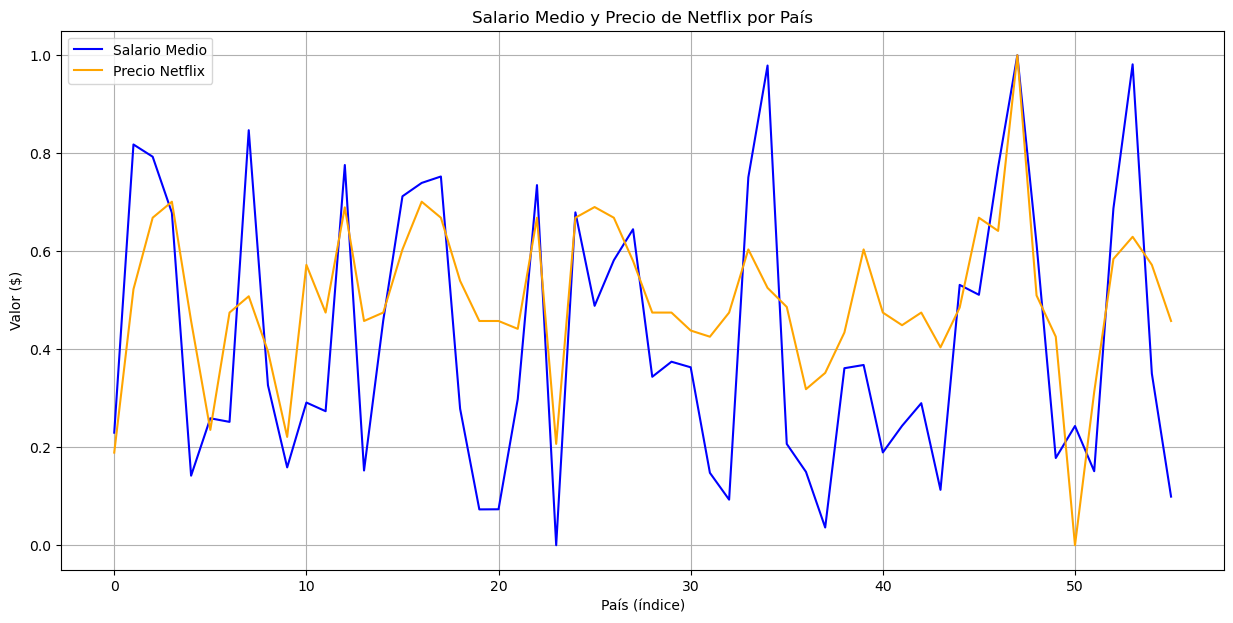

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,7))

# Linea Salario Medio
plt.plot(df_netflix_salaries["meanIncome"], label='Salario Medio', color='blue')

# Linea Precio Netflix
plt.plot(df_netflix_salaries["Cost Per Month - Standard ($)"], label='Precio Netflix', color='orange')

plt.title("Salario Medio y Precio de Netflix por Pais")
plt.xlabel("Pais (indice)")
plt.ylabel("Valor ($)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Correlacion
df_netflix_salaries.corr(numeric_only=True)

,Cost Per Month - Standard ($),meanIncome,medianIncome
Cost Per Month - Standard ($),1.000000,0.699928,0.709350
meanIncome,0.699928,1.000000,0.993419
medianIncome,0.709350,0.993419,1.000000
